## **Atelier Matplotlib**

**Introduction**

Cet atelier Matplotlib prolonge le travail effectué avec NumPy (manipulation numérique) et Pandas (import, nettoyage, analyse) sur le jeu de données de capteurs IoT. L'objectif est maintenant de **visualiser** ces données afin de faire apparaître des tendances, des différences entre bâtiments et des anomalies qu'un simple tableau de chiffres ne permet pas de repérer facilement.

L'atelier suit huit types de graphiques classiques : la courbe (**Partie 1**), le diagramme en barres (**Partie 2**), l'histogramme (**Partie 3**), le nuage de points (**Partie 4**), le diagramme à moustaches (**Partie 5**), le diagramme circulaire (**Partie 6**), la superposition de plusieurs courbes (**Partie 7**) et la sauvegarde de graphiques (**Partie 8**). Une partie bonus (**Partie 9**) complète l'atelier avec un tableau de bord synthétique.

Le jeu de données `mesures_capteurs.csv` contient, pour chaque mesure : un identifiant, une date/heure, un identifiant de capteur, un bâtiment (B001 à B004), la température (°C), l'humidité (%), la pression (hPa), la consommation énergétique (kWh) et l'état du capteur (OK, ALERTE, ERREUR). Comme dans l'atelier Pandas, ce jeu de données contient volontairement quelques valeurs manquantes et quelques valeurs aberrantes, ce qui permettra d'illustrer comment les graphiques aident à les repérer visuellement.

## Installer et importer matplotlib et pandas

In [4]:
# Import des bibliothèques nécessaires pour tout le notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Pandas version    :", pd.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)
print("NumPy version     :", np.__version__)

Matplotlib is building the font cache; this may take a moment.


Pandas version    : 3.0.3
Matplotlib version: 3.11.1
NumPy version     : 2.5.0


 Import de `mesures_capteurs.csv` dans le dataframe `df`

In [5]:
# Import du CSV dans le dataframe df
# Le chemin est relatif au notebook, situé dans notebooks/, le CSV est dans ../data/
df = pd.read_csv("../data/mesures_capteurs.csv")

# Conversion de la colonne date_heure en type datetime pour un tracé correct de l'axe temporel
df["date_heure"] = pd.to_datetime(df["date_heure"])

print("Dimensions du dataframe :", df.shape)
df.head()

Dimensions du dataframe : (605, 9)


,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


In [6]:
# Verifion rapidement des valeurs manquantes : utile pour anticiper les graphiques
# (certaines colonnes contiennent quelques NaN à gérer avant de tracer)
df.isna().sum()

id_mesure       0
date_heure      0
id_capteur      0
batiment        0
temperature     6
humidite        5
pression        5
consommation    5
etat            4
dtype: int64

## Partie 1 – Graphique linéaire (Line Plot)

1) Évolution de la température en fonction du temps, avec titre, labels, légende et grille

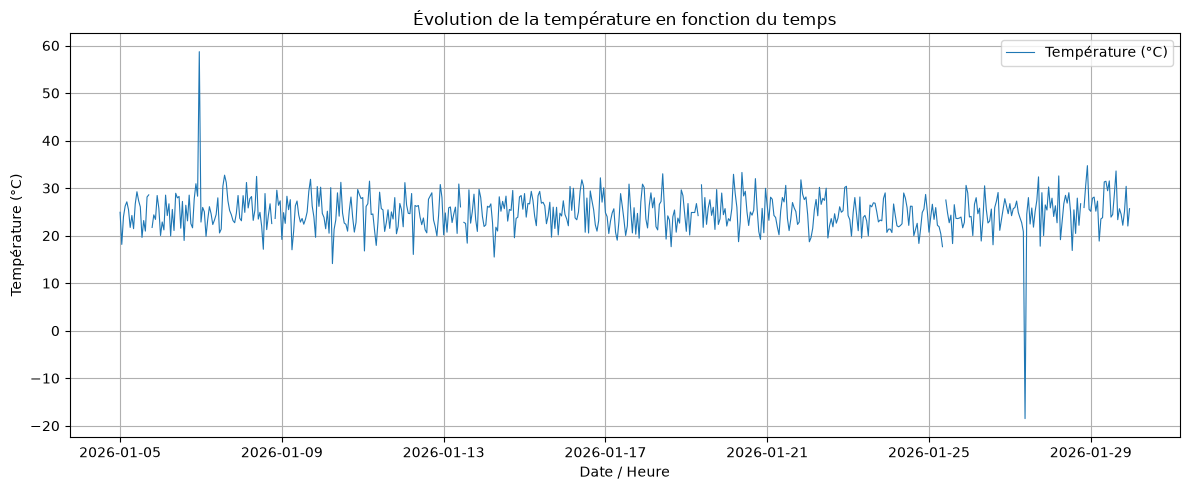

In [7]:
# On trie par date_heure pour que la courbe suive bien l'ordre chronologique
df_temps = df.sort_values("date_heure")

plt.figure(figsize=(12, 5))
plt.plot(df_temps["date_heure"], df_temps["temperature"],
         color="tab:blue", linewidth=0.8, label="Température (°C)")

plt.title("Évolution de la température en fonction du temps")
plt.xlabel("Date / Heure")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

2) Identification visuelle des valeurs qui semblent anormales

In [8]:
# Quelques repères chiffrés pour appuyer la lecture visuelle du graphique
print("Température minimale :", df["temperature"].min())
print("Température maximale :", df["temperature"].max())
print(df.nsmallest(3, "temperature")[["date_heure", "batiment", "temperature"]])
print(df.nlargest(3, "temperature")[["date_heure", "batiment", "temperature"]])

Température minimale : -18.5
Température maximale : 58.7
             date_heure batiment  temperature
487 2026-01-27 09:00:00     B004       -18.50
245 2026-01-10 06:00:00     B003        14.11
258 2026-01-14 06:00:00     B003        15.49
             date_heure batiment  temperature
502 2026-01-06 23:00:00     B004        58.70
43  2026-01-28 22:00:00     B004        34.72
129 2026-01-29 15:00:00     B002        33.60


**Explication**

Sur la courbe, l'immense majorité des points oscille dans une bande resserrée, à peu près entre 15 °C et 35 °C, avec de petites fluctuations d'une mesure à l'autre — un comportement cohérent avec des variations normales de température ambiante. Deux valeurs se détachent nettement de ce nuage : un point autour de **-18,5 °C**, physiquement improbable pour une mesure intérieure/ambiante, et un point autour de **58,7 °C**, largement au-dessus du reste des mesures. Ces deux valeurs forment des pics isolés, sans continuité avec les mesures voisines dans le temps, ce qui est typique d'une **erreur de capteur** (défaut de calibration, court-circuit, valeur de remplacement type -999 mal codée, etc.) plutôt que d'un phénomène physique réel.

###  Résumé — Partie 1 : Graphique linéaire

| Fonction / Méthode utilisée | Ce qu'elle fait | Alternative existante (non utilisée) | Différence avec l'alternative |
|---|---|---|---|
| `plt.plot(x, y)` | Trace une courbe reliant des points par des segments de droite | `plt.scatter(x, y)` | `scatter` affiche des points isolés sans les relier ; moins adapté pour suivre une évolution continue dans le temps. |
| `plt.title()` / `.xlabel()` / `.ylabel()` | Ajoute titre et légendes des axes | `plt.suptitle()` | `suptitle` place un titre au-dessus de plusieurs sous-graphiques (subplots), alors que `title()` s'applique à un seul axe. |
| `plt.legend()` | Affiche la légende à partir du paramètre `label=` des tracés | Placer le texte manuellement avec `plt.text()` | `text()` positionne une légende « à la main », sans lien automatique avec les couleurs/styles des courbes tracées. |
| `plt.grid(True)` | Affiche une grille sur les deux axes | `plt.grid(axis="y")` | Restreint la grille à un seul axe (utilisé en Partie 3 et 5 pour n'afficher que les lignes horizontales). |
| `df.nsmallest()` / `df.nlargest()` | Renvoie les n lignes avec les plus petites/grandes valeurs d'une colonne | `df.sort_values().head(n)` | Résultat identique ; `nsmallest`/`nlargest` est plus direct et légèrement plus rapide sur de grands jeux de données. |

## Partie 2 – Diagramme en barres (Bar Chart)

1) `consommation_batiment` : consommations moyennes des bâtiments

In [9]:
# Moyenne de la consommation par bâtiment (les NaN sont ignorés automatiquement par mean())
consommation_batiment = df.groupby("batiment")["consommation"].mean().sort_index()
consommation_batiment

batiment
B001    177.870927
B002    221.785333
B003    153.191000
B004    282.552282
Name: consommation, dtype: float64

2) Comparaison graphique de la consommation moyenne des bâtiments

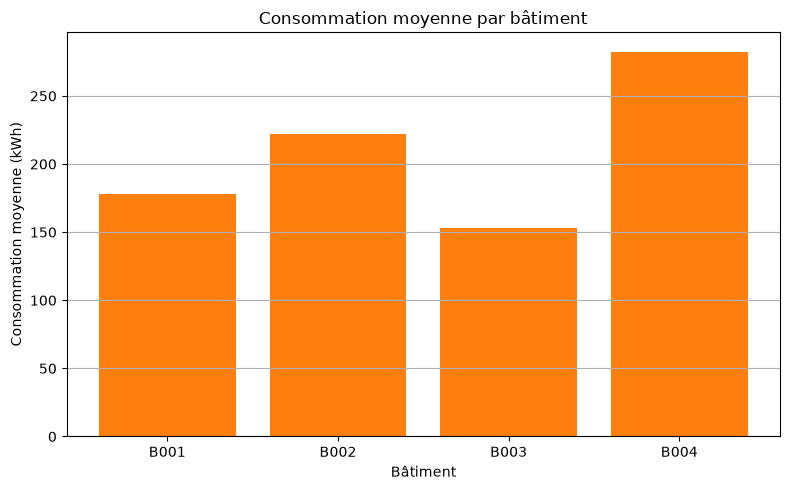

In [10]:
plt.figure(figsize=(8, 5))
plt.bar(consommation_batiment.index, consommation_batiment.values, color="tab:orange")

plt.title("Consommation moyenne par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Consommation moyenne (kWh)")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

3) Comparaison de la consommation moyenne des bâtiments avec un graphique horizontal

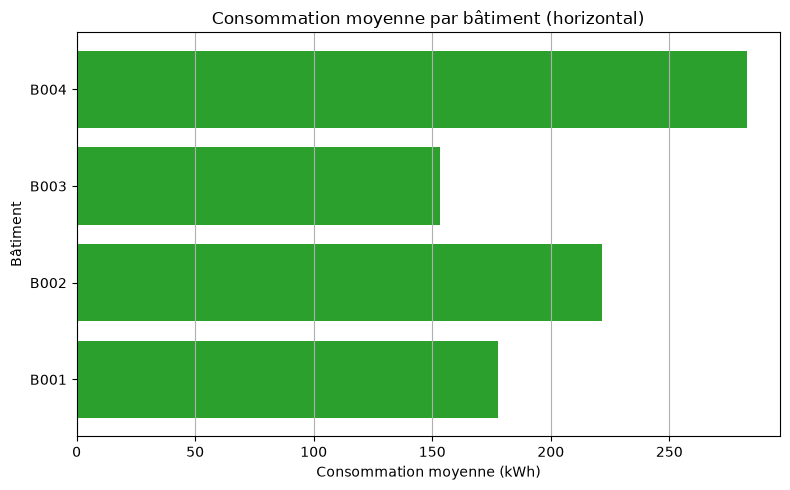

In [13]:
plt.figure(figsize=(8, 5))
plt.barh(consommation_batiment.index, consommation_batiment.values, color="tab:green")

plt.title("Consommation moyenne par bâtiment (horizontal)")
plt.xlabel("Consommation moyenne (kWh)")
plt.ylabel("Bâtiment")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

4) Dans quels cas un graphique horizontal peut-il être plus lisible ?

**Explication**

Un graphique en barres horizontal (`barh`) devient plus lisible qu'un graphique vertical dans plusieurs cas : lorsque les étiquettes des catégories sont **longues** (des noms de bâtiments complets plutôt que des codes courts comme ici, par exemple), car elles restent horizontales et ne se chevauchent pas comme elles le feraient en pivotant sous un axe vertical ; lorsqu'il y a **beaucoup de catégories** à comparer, l'orientation horizontale permet d'empiler les barres verticalement sans les compresser ; et lorsque l'on souhaite **classer visuellement** les catégories par ordre croissant/décroissant, l'œil suit alors naturellement une liste de haut en bas, un peu comme un classement. Ici, avec seulement 4 bâtiments et des codes courts (B001–B004), les deux orientations restent lisibles, mais l'horizontal serait clairement préférable avec, par exemple, une douzaine de bâtiments aux noms complets.

###  Résumé — Partie 2 : Diagramme en barres

| Fonction / Méthode utilisée | Ce qu'elle fait | Alternative existante (non utilisée) | Différence avec l'alternative |
|---|---|---|---|
| `df.groupby("col").mean()` | Calcule la moyenne d'une colonne numérique par groupe | `df.pivot_table(values=..., index="col", aggfunc="mean")` | Résultat équivalent ; `pivot_table` devient plus intéressant pour croiser plusieurs dimensions à la fois. |
| `plt.bar(x, y)` | Trace un diagramme en barres verticales | `plt.barh(x, y)` | `barh` trace les mêmes barres à l'horizontale (axes x/y inversés) ; utile pour les longues étiquettes. |
| `plt.barh(x, y)` | Trace un diagramme en barres horizontales | `df.plot(kind="barh")` | Résultat visuellement identique ; `df.plot()` est l'API graphique intégrée à Pandas, qui appelle Matplotlib en arrière-plan avec moins de code. |
| `plt.grid(axis="y")` / `axis="x"` | N'affiche la grille que sur un seul axe | `plt.grid(True)` | `grid(True)` affiche la grille sur les deux axes ; restreindre à un axe réduit le bruit visuel. |

## Partie 3 – Histogramme

1) Distribution des températures en 20 classes, en n'affichant que les lignes horizontales de la grille

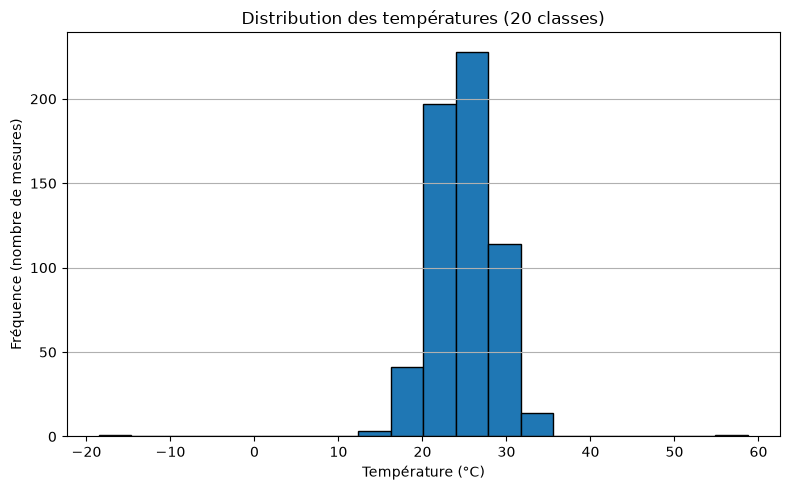

In [14]:
# dropna() car hist() ne gère pas les NaN
plt.figure(figsize=(8, 5))
plt.hist(df["temperature"].dropna(), bins=20, color="tab:blue", edgecolor="black")

plt.title("Distribution des températures (20 classes)")
plt.xlabel("Température (°C)")
plt.ylabel("Fréquence (nombre de mesures)")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

2) Analyse du graphique

**Explication**

- **a) Concentration des températures :** la grande majorité des mesures se concentre entre environ 18 °C et 32 °C, avec un pic autour de 24-25 °C, ce qui correspond à la moyenne calculée précédemment (≈ 24,9 °C).
- **b) Symétrie de la distribution :** la forme est globalement proche d'une distribution symétrique en cloche (proche d'une loi normale), sans asymétrie marquée vers la gauche ou la droite pour le corps principal des données.
- **c) Valeurs très éloignées :** deux barres quasi invisibles apparaissent très loin du groupe principal, une vers -18 °C et une vers +58 °C, séparées du reste par de larges classes vides.
- **d) Valeurs aberrantes visibles :** oui, ce sont précisément ces deux barres isolées repérées en (c), cohérentes avec les deux valeurs anormales déjà identifiées sur le graphique linéaire de la Partie 1.

3) Distribution de la consommation en 20 classes

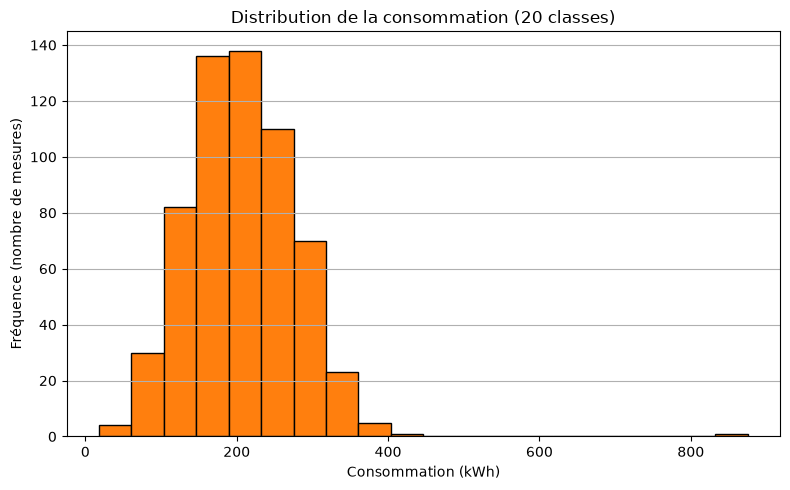

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(df["consommation"].dropna(), bins=20, color="tab:orange", edgecolor="black")

plt.title("Distribution de la consommation (20 classes)")
plt.xlabel("Consommation (kWh)")
plt.ylabel("Fréquence (nombre de mesures)")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

a) Modification du nombre de classes à 10

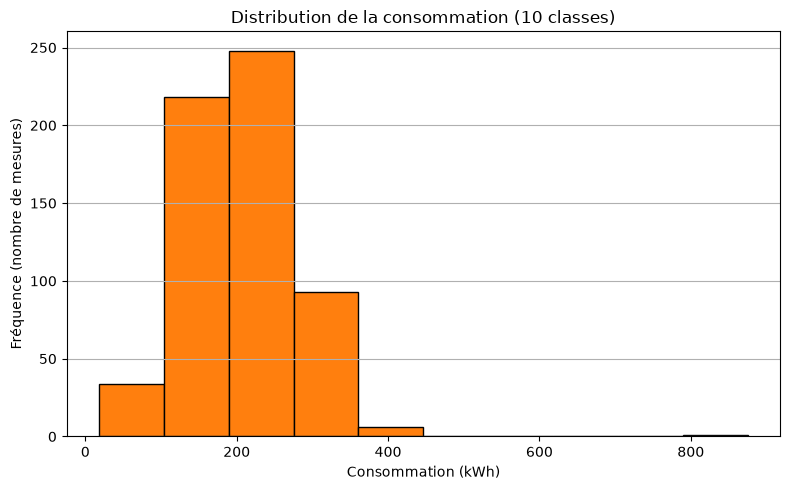

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(df["consommation"].dropna(), bins=10, color="tab:orange", edgecolor="black")

plt.title("Distribution de la consommation (10 classes)")
plt.xlabel("Consommation (kWh)")
plt.ylabel("Fréquence (nombre de mesures)")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

b) Modification du nombre de classes à 30

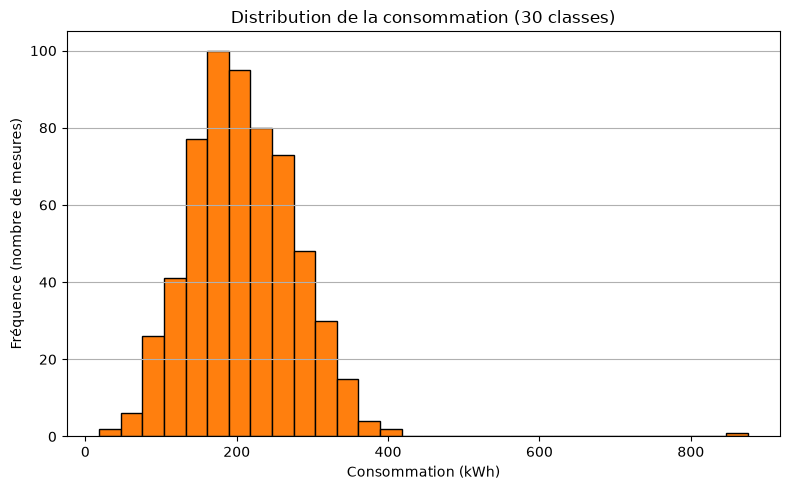

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(df["consommation"].dropna(), bins=30, color="tab:orange", edgecolor="black")

plt.title("Distribution de la consommation (30 classes)")
plt.xlabel("Consommation (kWh)")
plt.ylabel("Fréquence (nombre de mesures)")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

c) Quel impact le nombre de classes a-t-il sur l'interprétation ?

**Explication**

Le nombre de classes (`bins`) contrôle directement le niveau de détail de l'histogramme. Avec **10 classes**, les barres sont larges : la forme générale de la distribution (où se situe le pic, la dispersion globale) ressort clairement, mais les détails fins et les petites irrégularités sont lissés/masqués. Avec **30 classes**, les barres sont plus fines et plus nombreuses : on distingue mieux les variations locales et les valeurs isolées (comme le pic de consommation à 875 kWh), mais le graphique devient plus « bruité » et la tendance générale est un peu plus difficile à percevoir d'un coup d'œil. Il existe donc un compromis classique en visualisation de données : trop peu de classes fait perdre de l'information (sous-lissage), trop de classes fait ressortir du bruit statistique difficile à interpréter (sur-lissage) ; 20 classes (valeur par défaut demandée en 3.1) offre ici un bon équilibre pour ce jeu de données.

###  Résumé — Partie 3 : Histogramme

| Fonction / Méthode utilisée | Ce qu'elle fait | Alternative existante (non utilisée) | Différence avec l'alternative |
|---|---|---|---|
| `plt.hist(data, bins=n)` | Trace un histogramme en répartissant les données en n classes | `df["col"].plot(kind="hist", bins=n)` | Résultat équivalent via l'API graphique intégrée à Pandas, qui appelle Matplotlib en arrière-plan. |
| `.dropna()` | Retire les valeurs manquantes avant le tracé | `.fillna(valeur)` | `fillna` remplacerait les NaN par une valeur (ex. la moyenne) au lieu de les supprimer, ce qui modifierait artificiellement la distribution. |
| `bins=10` / `bins=20` / `bins=30` | Fixe le nombre de classes de l'histogramme | `bins="auto"` | Laisse Matplotlib/NumPy choisir automatiquement un nombre de classes adapté à la dispersion des données. |
| `edgecolor="black"` | Ajoute un contour aux barres | *(aucune alternative directe)* | Améliore la lisibilité en distinguant visuellement les barres adjacentes de même couleur. |

## Partie 4 – Nuage de points (Scatter Plot)

1) Nuage de points entre température et consommation

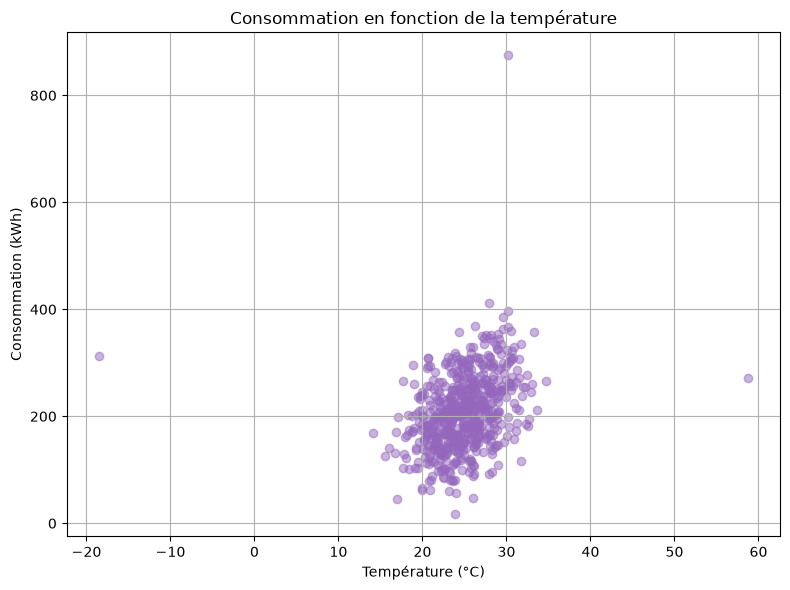

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(df["temperature"], df["consommation"], alpha=0.5, color="tab:purple")

plt.title("Consommation en fonction de la température")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation (kWh)")
plt.grid(True)
plt.tight_layout()
plt.show()

2) Existe-t-il visuellement une relation entre les deux ?

In [20]:
# Coefficient de corrélation linéaire, pour appuyer la lecture visuelle du nuage de points
correlation = df["temperature"].corr(df["consommation"])
print(f"Corrélation température / consommation : {correlation:.2f}")

Corrélation température / consommation : 0.32


**Explication**

Le nuage de points ne montre pas de relation nette et régulière entre température et consommation : les points forment un nuage assez diffus, sans alignement clair le long d'une droite ou d'une courbe. Le coefficient de corrélation calculé (≈ 0,3) confirme cette lecture visuelle : il indique une **corrélation positive faible à modérée** (quand la température monte, la consommation a légèrement tendance à augmenter aussi, sans doute liée à la climatisation ou aux équipements de refroidissement), mais la relation est loin d'être forte ou déterministe. D'autres facteurs non représentés ici (heure de la journée, bâtiment, type d'équipement) influencent probablement davantage la consommation que la seule température.

###  Résumé — Partie 4 : Nuage de points

| Fonction / Méthode utilisée | Ce qu'elle fait | Alternative existante (non utilisée) | Différence avec l'alternative |
|---|---|---|---|
| `plt.scatter(x, y)` | Affiche un point pour chaque paire de valeurs (x, y) | `plt.plot(x, y, "o")` | `plot` avec un style de marqueur sans ligne (`"o"`) produit un résultat visuellement proche, mais `scatter` offre plus d'options natives (taille, couleur variable par point, transparence). |
| `alpha=0.5` | Rend les points semi-transparents | *(aucune alternative directe)* | Utile pour repérer les zones de forte densité de points qui se superposent, invisible avec des points totalement opaques. |
| `Series.corr()` | Calcule le coefficient de corrélation linéaire (Pearson par défaut) entre deux colonnes | `np.corrcoef(x, y)` | Résultat équivalent ; `np.corrcoef` renvoie une matrice de corrélation complète plutôt qu'une seule valeur. |

## Partie 5 – Diagramme à moustaches (Box plot)

1) Box plot de la température (valeurs manquantes supprimées), en n'affichant que les lignes horizontales de la grille

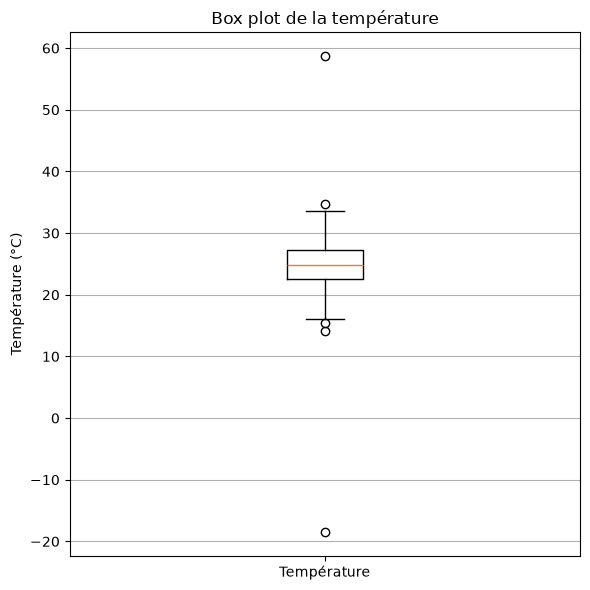

In [21]:
temperature_clean = df["temperature"].dropna()

plt.figure(figsize=(6, 6))
plt.boxplot(temperature_clean, tick_labels=["Température"])

plt.title("Box plot de la température")
plt.ylabel("Température (°C)")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

2) Que représentent les points situés en dehors des moustaches ?

**Explication**

Les points affichés individuellement au-delà des moustaches sont les **valeurs aberrantes (outliers)** au sens statistique : ce sont des mesures situées à plus de 1,5 fois l'écart interquartile (IQR = Q3 - Q1) au-dessus de Q3 ou en dessous de Q1. Ici, on retrouve logiquement les deux valeurs extrêmes déjà repérées en Parties 1 et 3 (autour de -18 °C et 58 °C), que le box plot met en évidence de façon très synthétique, sans avoir besoin de relire l'ensemble de la courbe ou de l'histogramme.

3) Box plot de la consommation

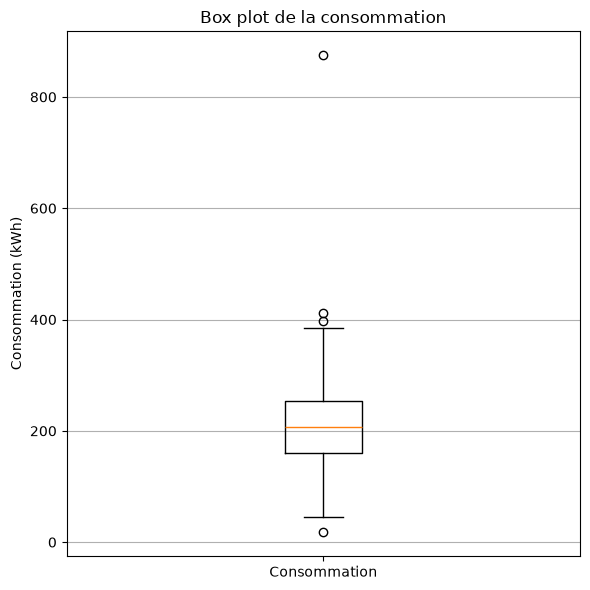

In [22]:
consommation_clean = df["consommation"].dropna()

plt.figure(figsize=(6, 6))
plt.boxplot(consommation_clean, tick_labels=["Consommation"])

plt.title("Box plot de la consommation")
plt.ylabel("Consommation (kWh)")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

4) Comparaison des deux box plots

**Explication**

- **a) Position de la médiane :** la médiane de la température se situe autour de 25 °C, bien centrée dans sa boîte ; celle de la consommation se situe autour de 206 kWh, également assez centrée, mais dans une échelle de valeurs totalement différente (kWh contre °C).
- **b) Taille de la boîte (IQR) :** la boîte de la consommation est, en proportion de son échelle, plus large que celle de la température : l'écart interquartile de la consommation représente une part importante de sa plage de valeurs usuelles, traduisant une variabilité plus marquée d'un bâtiment/moment à l'autre.
- **c) Longueur des moustaches :** les moustaches de la température restent relativement courtes et resserrées autour de la boîte ; celles de la consommation s'étendent davantage vers les valeurs hautes, signe d'une distribution plus étalée du côté des fortes consommations.
- **d) Valeurs extrêmes :** la température affiche deux outliers très marqués (un très bas, un très haut) ; la consommation affiche surtout un ou plusieurs outliers hauts (dont le pic à 875 kWh), sans outlier bas comparable.

5) **La consommation présente-t-elle davantage de dispersion que la température ?** En valeur absolue les deux variables ne sont pas comparables (kWh contre °C), mais en dispersion **relative** (écart-type rapporté à la moyenne), la consommation est nettement plus dispersée : son écart-type représente environ 35 % de sa moyenne, contre environ 16 % pour la température. La consommation varie donc proportionnellement beaucoup plus que la température d'une mesure à l'autre.

In [23]:
# Vérification chiffrée de la dispersion relative (coefficient de variation)
cv_temp = df["temperature"].std() / df["temperature"].mean()
cv_conso = df["consommation"].std() / df["consommation"].mean()
print(f"Coefficient de variation - température  : {cv_temp:.2%}")
print(f"Coefficient de variation - consommation : {cv_conso:.2%}")

Coefficient de variation - température  : 16.32%
Coefficient de variation - consommation : 34.62%


###  Résumé — Partie 5 : Box plot

| Fonction / Méthode utilisée | Ce qu'elle fait | Alternative existante (non utilisée) | Différence avec l'alternative |
|---|---|---|---|
| `plt.boxplot(data)` | Trace un diagramme à moustaches (médiane, quartiles, moustaches, outliers) | `df.boxplot(column="col")` | Résultat équivalent via l'API graphique intégrée à Pandas, qui appelle Matplotlib en arrière-plan. |
| `tick_labels=[...]` | Nomme la/les catégories affichées sur l'axe | *(paramètre historique `labels=`)* | `labels=` reste accepté dans certaines versions de Matplotlib mais est en cours de dépréciation au profit de `tick_labels=`. |
| Coefficient de variation (`std / mean`) | Mesure la dispersion relative d'une variable, indépendamment de son échelle | Comparaison directe des écarts-types | Comparer deux écarts-types bruts n'a de sens que si les variables sont sur la même échelle ; le coefficient de variation permet de comparer équitablement température (°C) et consommation (kWh). |

## Partie 6 – Diagramme circulaire (Pie Chart)

1) Répartition des états (OK, ALERTE, ERREUR)

In [26]:
# Comptage des états ; les valeurs manquantes (NaN) sont exclues par défaut par value_counts()
repartition_etats = df["etat"].value_counts()
repartition_etats

etat
OK        567
ALERTE     29
ERREUR      5
Name: count, dtype: int64

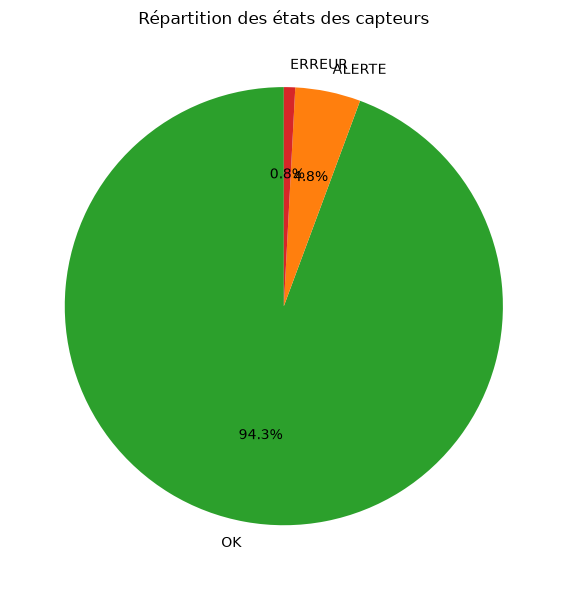

In [27]:
plt.figure(figsize=(6, 6))
plt.pie(repartition_etats.values, labels=repartition_etats.index,
        autopct="%1.1f%%", colors=["tab:green", "tab:orange", "tab:red"], startangle=90)

plt.title("Répartition des états des capteurs")
plt.tight_layout()
plt.show()

2) Interprétation des proportions

**Explication**

La très grande majorité des mesures (environ 93-94 %) sont enregistrées avec l'état **OK**, ce qui indique un fonctionnement globalement sain du parc de capteurs sur la période observée. L'état **ALERTE** concerne une petite minorité des mesures (environ 5 %), ce qui reste à surveiller mais ne traduit pas une situation critique généralisée. L'état **ERREUR**, le moins fréquent (moins de 1 %), correspond probablement aux quelques capteurs ayant produit les valeurs aberrantes déjà repérées dans les parties précédentes (température à -18 °C ou 58 °C, consommation à 875 kWh). Ces proportions confirment qu'il s'agit d'anomalies ponctuelles et isolées plutôt que d'un dysfonctionnement massif du système.

###  Résumé — Partie 6 : Diagramme circulaire

| Fonction / Méthode utilisée | Ce qu'elle fait | Alternative existante (non utilisée) | Différence avec l'alternative |
|---|---|---|---|
| `Series.value_counts()` | Compte le nombre d'occurrences de chaque valeur unique | `df.groupby("col").size()` | Résultat équivalent, mais `value_counts()` trie déjà par ordre décroissant et exclut les NaN par défaut. |
| `plt.pie(values, labels=...)` | Trace un diagramme circulaire | `plt.bar(labels, values)` | Un diagramme en barres compare mieux des valeurs proches ; le camembert reste plus intuitif pour lire des **proportions** d'un tout. |
| `autopct="%1.1f%%"` | Affiche le pourcentage de chaque part directement sur le graphique | Ajouter une légende avec `plt.legend()` | La légende identifie les catégories par couleur, mais n'affiche pas automatiquement leur poids relatif comme `autopct`. |

## Partie 7 : Plusieurs courbes sur un même graphique

Évolution de la température par bâtiment, pour les quatre bâtiments, sur un même graphique

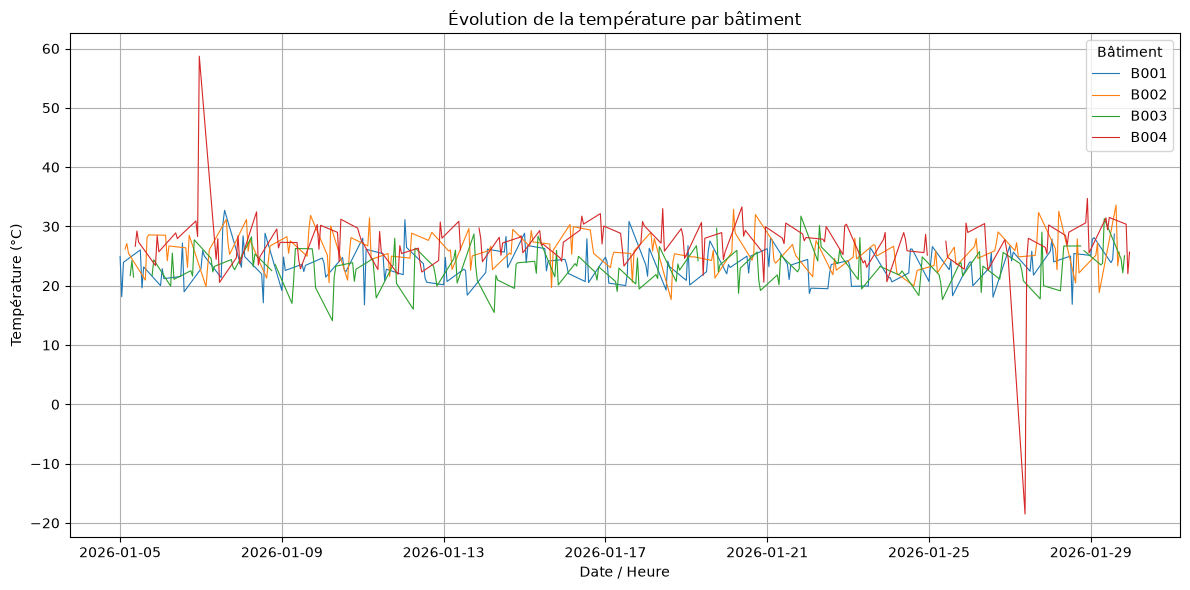

In [28]:
plt.figure(figsize=(12, 6))

for batiment in sorted(df["batiment"].unique()):
    sous_df = df[df["batiment"] == batiment].sort_values("date_heure")
    plt.plot(sous_df["date_heure"], sous_df["temperature"], label=batiment, linewidth=0.8)

plt.title("Évolution de la température par bâtiment")
plt.xlabel("Date / Heure")
plt.ylabel("Température (°C)")
plt.legend(title="Bâtiment")
plt.grid(True)
plt.tight_layout()
plt.show()

**Explication**

Superposer les quatre courbes sur un même graphique permet de comparer directement les bâtiments entre eux, sans avoir à mémoriser quatre graphiques séparés. On observe que les quatre bâtiments évoluent dans des plages de température globalement proches et se chevauchent largement, sans qu'un bâtiment ne se détache par une tendance thermique très différente des autres. Les deux valeurs aberrantes déjà identifiées apparaissent ici clairement rattachées au bâtiment **B004** (le pic extrême à 58 °C), ce qui aide à cibler précisément quel bâtiment/capteur mérite une vérification en priorité — une information moins immédiate à lire sur la courbe globale de la Partie 1.

###  Résumé — Partie 7 : Plusieurs courbes

| Fonction / Méthode utilisée | Ce qu'elle fait | Alternative existante (non utilisée) | Différence avec l'alternative |
|---|---|---|---|
| Boucle `for` + `plt.plot()` répété | Trace une courbe par bâtiment sur les mêmes axes | `df.pivot_table` puis `df.plot()` | Une table pivotée (dates en index, bâtiments en colonnes) permettrait de tracer les 4 courbes en un seul appel `plot()`, sans boucle explicite. |
| `label=batiment` dans la boucle | Attribue une étiquette différente à chaque courbe pour la légende | Construire la légende manuellement avec `plt.legend(["B001", ...])` | Passer les labels un par un dans `plot()` reste synchronisé automatiquement avec les couleurs, contrairement à une liste de légendes construite à part. |
| `plt.legend(title=...)` | Ajoute un titre au-dessus de la légende | *(aucune alternative directe)* | Précise ce que représentent les différentes couleurs (ici, les bâtiments). |

## Partie 8 : Sauvegarde des graphiques

1) Sauvegarde du graphique de l'évolution de la température en fonction du temps dans `exports/temperature.png`

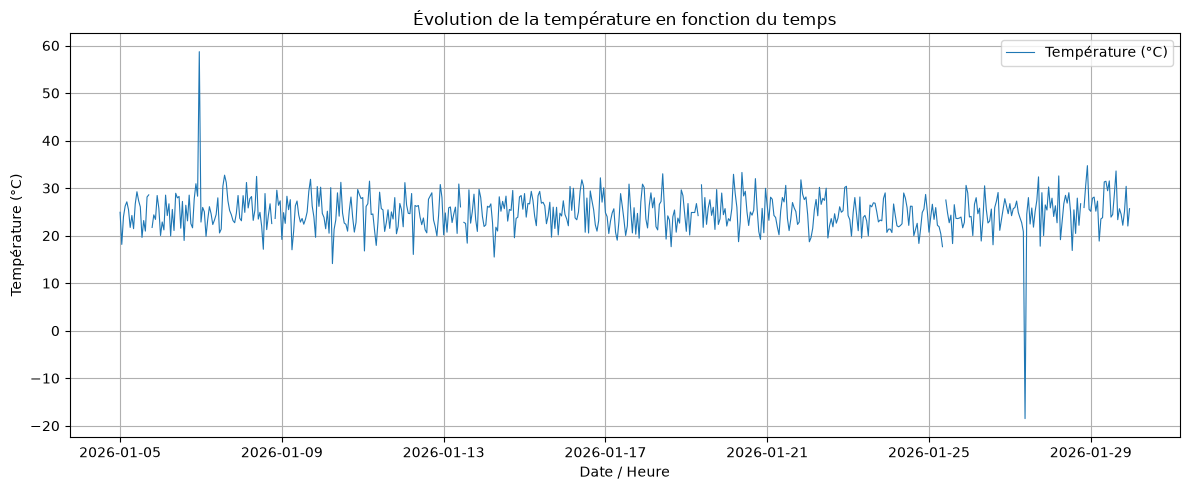

Graphique enregistré dans exports/temperature.png


In [29]:
df_temps = df.sort_values("date_heure")

plt.figure(figsize=(12, 5))
plt.plot(df_temps["date_heure"], df_temps["temperature"],
         color="tab:blue", linewidth=0.8, label="Température (°C)")
plt.title("Évolution de la température en fonction du temps")
plt.xlabel("Date / Heure")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Sauvegarde en PNG (image matricielle, format le plus courant pour le web/rapports)
plt.savefig("../exports/temperature.png", dpi=150)
plt.show()

print("Graphique enregistré dans exports/temperature.png")

2) Sauvegarde du même graphique dans `exports/temperature.pdf`

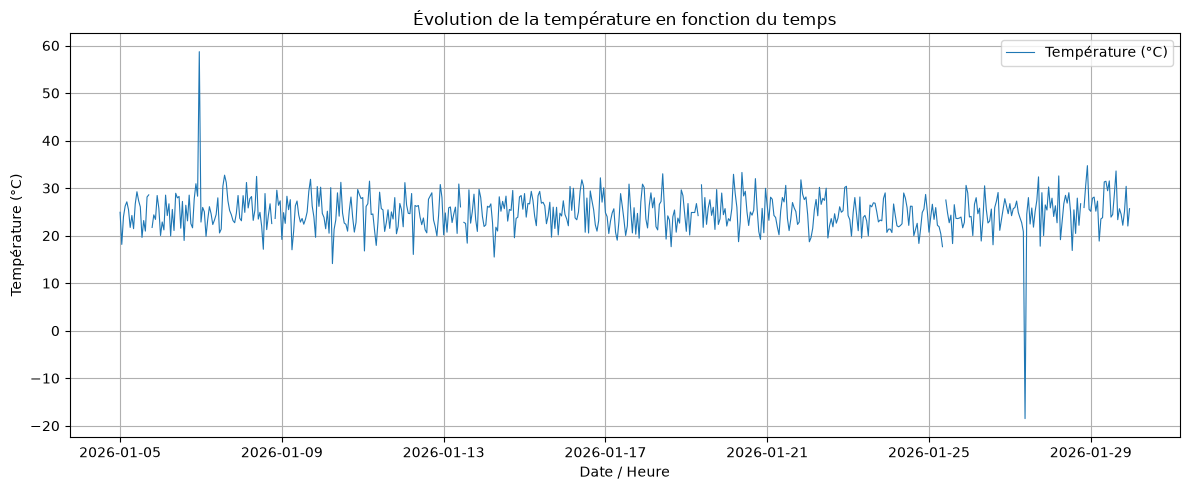

Graphique enregistré dans exports/temperature.pdf


In [30]:
df_temps = df.sort_values("date_heure")

plt.figure(figsize=(12, 5))
plt.plot(df_temps["date_heure"], df_temps["temperature"],
         color="tab:blue", linewidth=0.8, label="Température (°C)")
plt.title("Évolution de la température en fonction du temps")
plt.xlabel("Date / Heure")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Sauvegarde en PDF (format vectoriel, qualité conservée à n'importe quel zoom, idéal pour l'impression)
plt.savefig("../exports/temperature.pdf")
plt.show()

print("Graphique enregistré dans exports/temperature.pdf")

###  Résumé — Partie 8 : Sauvegarde des graphiques

| Fonction / Méthode utilisée | Ce qu'elle fait | Alternative existante (non utilisée) | Différence avec l'alternative |
|---|---|---|---|
| `plt.savefig("chemin.png", dpi=150)` | Enregistre le graphique courant en image matricielle (PNG) | `plt.savefig("chemin.jpg")` | Le JPEG utilise une compression avec perte, déconseillée pour des graphiques avec du texte fin (contours moins nets qu'en PNG). |
| `plt.savefig("chemin.pdf")` | Enregistre le graphique courant en format vectoriel (PDF) | `plt.savefig("chemin.svg")` | Le SVG est aussi vectoriel et davantage adapté à une intégration web ; le PDF reste la référence pour l'impression et les rapports. |
| `dpi=150` | Fixe la résolution (points par pouce) de l'export matriciel | `dpi=300` | Une résolution plus élevée donne une image plus nette mais un fichier plus lourd ; 150 dpi est déjà correct pour un affichage écran. |

## Partie 9 : Bonus — Tableau de bord synthétique & détection visuelle d'anomalies

Dans un contexte réel de supervision IoT, un technicien n'a pas le temps de faire défiler huit graphiques séparés pour évaluer l'état général du parc de capteurs. La fonctionnalité bonus proposée ici est un **tableau de bord (dashboard)** qui rassemble, sur une seule figure à plusieurs sous-graphiques (`plt.subplots`), les indicateurs les plus utiles :

1. l'évolution de la température par bâtiment (comme en Partie 7) ;
2. la consommation moyenne par bâtiment (comme en Partie 2) ;
3. la répartition des états des capteurs (comme en Partie 6) ;
4. le nuage de points température / consommation, avec les points en **ALERTE/ERREUR mis en évidence** en rouge, pour repérer en un coup d'œil les mesures à risque plutôt que de les chercher manuellement dans le tableau.

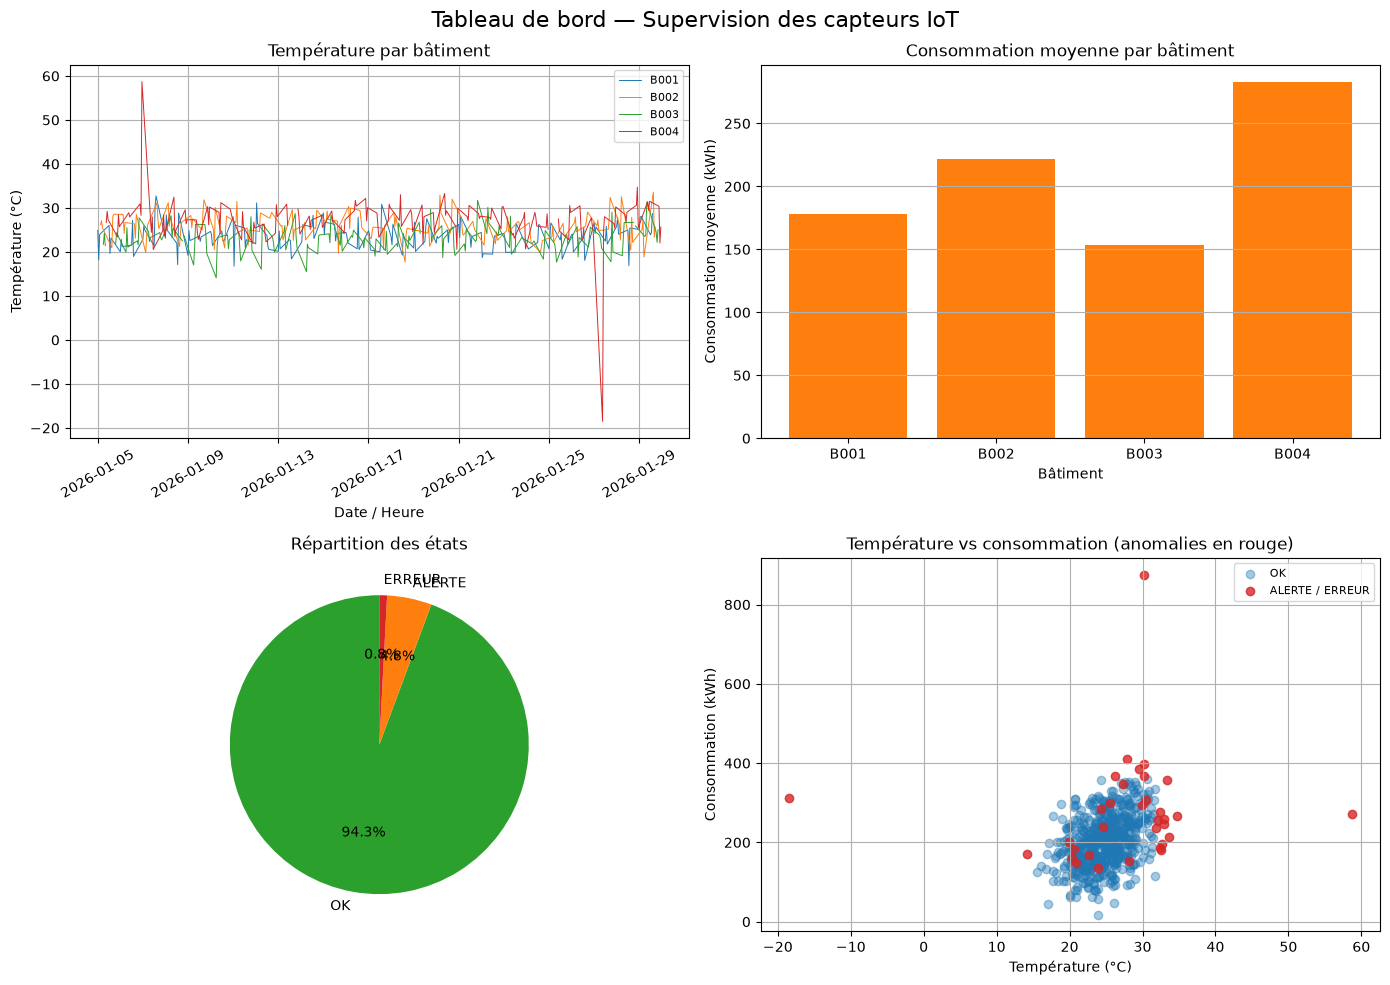

Tableau de bord enregistré dans exports/dashboard.png


In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- 1) Température par bâtiment ---
ax = axes[0, 0]
for batiment in sorted(df["batiment"].unique()):
    sous_df = df[df["batiment"] == batiment].sort_values("date_heure")
    ax.plot(sous_df["date_heure"], sous_df["temperature"], label=batiment, linewidth=0.7)
ax.set_title("Température par bâtiment")
ax.set_xlabel("Date / Heure")
ax.set_ylabel("Température (°C)")
ax.legend(fontsize=8)
ax.grid(True)
ax.tick_params(axis="x", rotation=30)

# --- 2) Consommation moyenne par bâtiment ---
ax = axes[0, 1]
ax.bar(consommation_batiment.index, consommation_batiment.values, color="tab:orange")
ax.set_title("Consommation moyenne par bâtiment")
ax.set_xlabel("Bâtiment")
ax.set_ylabel("Consommation moyenne (kWh)")
ax.grid(axis="y")

# --- 3) Répartition des états ---
ax = axes[1, 0]
ax.pie(repartition_etats.values, labels=repartition_etats.index,
       autopct="%1.1f%%", colors=["tab:green", "tab:orange", "tab:red"], startangle=90)
ax.set_title("Répartition des états")

# --- 4) Température vs consommation, alertes/erreurs en évidence ---
ax = axes[1, 1]
df_ok = df[df["etat"] == "OK"]
df_risque = df[df["etat"].isin(["ALERTE", "ERREUR"])]
ax.scatter(df_ok["temperature"], df_ok["consommation"], alpha=0.4, color="tab:blue", label="OK")
ax.scatter(df_risque["temperature"], df_risque["consommation"], alpha=0.8, color="tab:red", label="ALERTE / ERREUR")
ax.set_title("Température vs consommation (anomalies en rouge)")
ax.set_xlabel("Température (°C)")
ax.set_ylabel("Consommation (kWh)")
ax.legend(fontsize=8)
ax.grid(True)

fig.suptitle("Tableau de bord — Supervision des capteurs IoT", fontsize=16)
plt.tight_layout()

# Export du tableau de bord complet, pour partage ou impression
plt.savefig("../exports/dashboard.png", dpi=150)
plt.show()

print("Tableau de bord enregistré dans exports/dashboard.png")

**Bilan** de la partie bonus :

- Rassembler quatre graphiques clés en une seule figure avec `plt.subplots(2, 2, ...)` donne une vision d'ensemble immédiate de l'état du parc de capteurs, sans avoir à naviguer entre plusieurs graphiques séparés.
- Mettre en évidence les mesures **ALERTE/ERREUR** en rouge sur le nuage de points permet de vérifier visuellement si les anomalies de température ou de consommation se recoupent avec les anomalies déjà signalées par l'état du capteur, ou si elles sont indépendantes.
- Ce type de tableau de bord est directement réutilisable pour un export régulier (quotidien/hebdomadaire) destiné aux équipes de maintenance, sans écrire de rapport séparé pour chaque graphique.

## Conclusion générale — Atelier Matplotlib (IoT)

Cet atelier a permis de couvrir les principaux types de graphiques utilisés en analyse de données, appliqués au jeu de données de capteurs IoT déjà exploré avec Pandas. La courbe (Partie 1) a permis de suivre l'évolution temporelle de la température et de repérer deux valeurs aberrantes évidentes. Le diagramme en barres (Partie 2) a comparé la consommation moyenne entre bâtiments, avec une variante horizontale plus adaptée à certains contextes.

L'histogramme (Partie 3) a détaillé la forme de la distribution des températures et de la consommation, en montrant l'impact du choix du nombre de classes sur la lecture des données. Le nuage de points (Partie 4) a permis d'évaluer visuellement, puis chiffrer, une relation faible à modérée entre température et consommation. Le box plot (Partie 5) a synthétisé médiane, dispersion et valeurs extrêmes des deux variables, confirmant une dispersion relative plus forte pour la consommation. Le diagramme circulaire (Partie 6) a quantifié la proportion de capteurs en état OK, ALERTE et ERREUR.

La superposition de plusieurs courbes (Partie 7) a permis de comparer directement les quatre bâtiments et d'identifier le bâtiment porteur de l'anomalie de température la plus extrême. La sauvegarde des graphiques (Partie 8) a montré la différence entre export matriciel (PNG) et vectoriel (PDF). Enfin, la partie bonus (Partie 9) a réuni ces enseignements dans un tableau de bord synthétique, orienté vers un usage professionnel de supervision.

Globalement, les graphiques ont confirmé et enrichi les constats déjà faits avec Pandas (valeurs manquantes, valeurs aberrantes, différences entre bâtiments), tout en les rendant beaucoup plus immédiats à interpréter qu'une lecture de tableaux de chiffres.